# Analyse exploratoire — Estimation de la valeur marchande (EA Sports FC / FIFA)

**Objectif métier** : comprendre les données avant modélisation pour justifier
(1) la transformation de la cible, (2) la sélection des variables, (3) le choix des modèles.

> ⚠️ **Donnée synthétique** : si le vrai `male_players.csv` n'est pas présent, ce notebook
> tourne sur l'échantillon synthétique généré par `src/data/make_dataset.py`. Les *formes*
> de distribution sont réalistes mais les chiffres n'ont pas de valeur métier. Remplacez par
> le vrai dataset Kaggle pour une analyse réelle (cf. README).

Cette EDA démontre la compétence **C3.2** (analyse exploratoire et data visualisation).

In [1]:
import os, sys
sys.path.insert(0, os.path.abspath(".."))
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from src.config import load_config
from src.data.loader import load_raw_data
from src.data.make_dataset import generate

sns.set_theme(style="whitegrid")
config = load_config("../config/params.yaml")
path = "../" + config["data"]["raw_path"]
if not os.path.exists(path):
    os.makedirs(os.path.dirname(path), exist_ok=True)
    generate(5000).to_csv(path, index=False)
df = load_raw_data(path, config["data"]["fifa_version"])
print("Dimensions :", df.shape)
df.head(3)

2026-06-29 10:50:36 — src.data.loader — INFO — Loading data from ../data/raw/male_players.csv


2026-06-29 10:50:36 — src.data.loader — INFO — Raw shape: (5000, 56)


2026-06-29 10:50:36 — src.data.loader — INFO — Filtered to FIFA 24.0 update 3: 2520 players


Dimensions : (2520, 56)


,overall,potential,age,height_cm,weight_kg,weak_foot,skill_moves,international_reputation,pace,shooting,...,goalkeeping_positioning,goalkeeping_reflexes,goalkeeping_speed,preferred_foot,work_rate,fifa_version,fifa_update,short_name,player_url,value_eur
0,58,60,24,182,71,5,4,1,53,65,...,21,15,14.0,Right,Medium/High,24.0,3,Player 1,https://sofifa.com/player/0000,98000.0
1,70,70,22,172,68,4,2,1,79,61,...,18,7,16.0,Right,Low/Low,24.0,3,Player 2,https://sofifa.com/player/0000,888000.0
2,51,51,26,182,75,1,1,1,35,63,...,14,9,17.0,Left,High/High,24.0,3,Player 4,https://sofifa.com/player/0000,43000.0


## 1. Aperçu & types

In [2]:
print(df[['overall','potential','age','value_eur']].describe().round(0))
print('\nValeurs manquantes (top 8) :')
print(df.isna().sum().sort_values(ascending=False).head(8))

       overall  potential     age  value_eur
count   2520.0     2520.0  2520.0     2520.0
mean      65.0       67.0    25.0   399692.0
std        7.0        7.0     5.0   414160.0
min       47.0       47.0    16.0    11000.0
25%       60.0       62.0    22.0   148750.0
50%       65.0       67.0    25.0   271000.0
75%       69.0       72.0    28.0   499250.0
max       89.0       93.0    41.0  5140000.0

Valeurs manquantes (top 8) :
goalkeeping_speed    311
overall                0
age                    0
potential              0
weight_kg              0
weak_foot              0
skill_moves            0
height_cm              0
dtype: int64


## 2. La cible `value_eur` : pourquoi un `log1p` ?

La valeur marchande est **très asymétrique** (quelques stars valent 100×+ la médiane).
Un modèle de régression sur l'échelle brute serait dominé par ces extrêmes. On compare
la distribution brute et `log1p`.

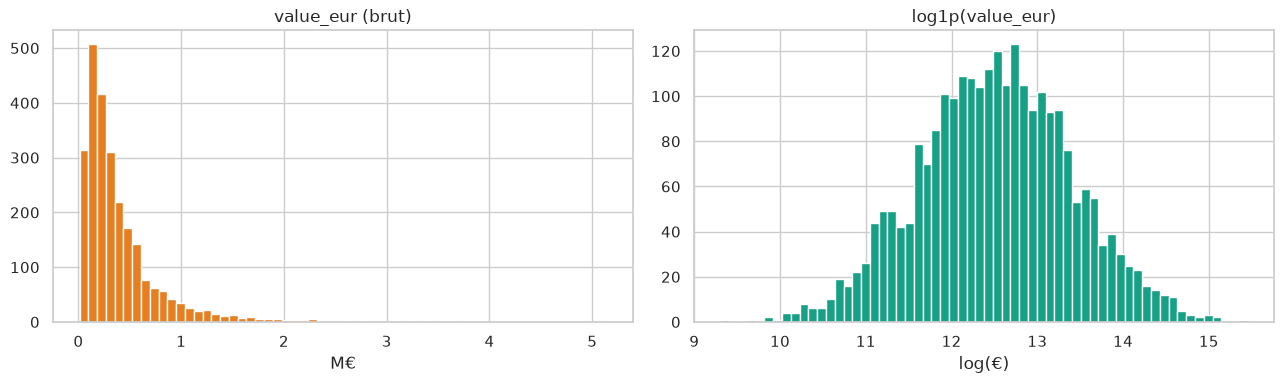

Skewness brut : 3.18 | après log1p : -0.03


In [3]:
fig, ax = plt.subplots(1, 2, figsize=(13,4))
ax[0].hist(df['value_eur']/1e6, bins=60, color='#e67e22')
ax[0].set_title('value_eur (brut)'); ax[0].set_xlabel('M€')
ax[1].hist(np.log1p(df['value_eur']), bins=60, color='#16a085')
ax[1].set_title('log1p(value_eur)'); ax[1].set_xlabel('log(€)')
plt.tight_layout(); plt.show()
print('Skewness brut :', round(df['value_eur'].skew(),2),
      '| après log1p :', round(np.log1p(df['value_eur']).skew(),2))

**Conclusion** : le `log1p` réduit fortement l'asymétrie → distribution quasi-symétrique,
adaptée à une régression. C'est la transformation appliquée dans `compare.py` (cible
`np.log1p`, prédictions ramenées en euros via `np.expm1`).

## 3. Variables les plus corrélées à la valeur

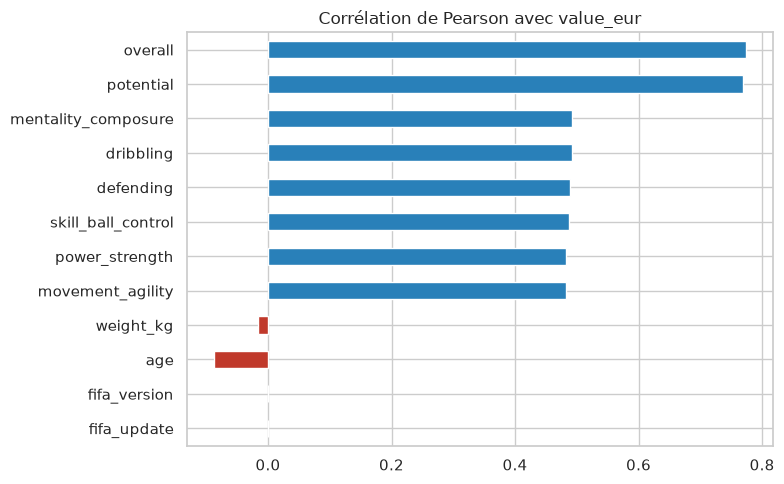

overall                0.774
potential              0.768
mentality_composure    0.492
dribbling              0.492
defending              0.489
skill_ball_control     0.487
power_strength         0.482
movement_agility       0.482
weight_kg             -0.016
age                   -0.088
fifa_version             NaN
fifa_update              NaN
Name: value_eur, dtype: float64

In [4]:
num = df.select_dtypes('number')
corr = num.corr(numeric_only=True)['value_eur'].drop('value_eur').sort_values(ascending=False)
top = pd.concat([corr.head(8), corr.tail(4)])
fig, ax = plt.subplots(figsize=(8,5))
top.plot.barh(ax=ax, color=np.where(top>0,'#2980b9','#c0392b'))
ax.set_title("Corrélation de Pearson avec value_eur"); ax.invert_yaxis()
plt.tight_layout(); plt.show()
top.round(3)

**Lecture** : `overall` et `potential` dominent, ce qui est cohérent métier. Les stats de
gardien sont quasi nulles pour la masse (joueurs de champ) → d'où leur imputation à 0 et le
mode « gardien » du dashboard.

## 4. Feature engineering : `potential_gap = potential − overall`

Signal de scouting central : un grand écart = joueur jeune **sous-coté** à fort upside.

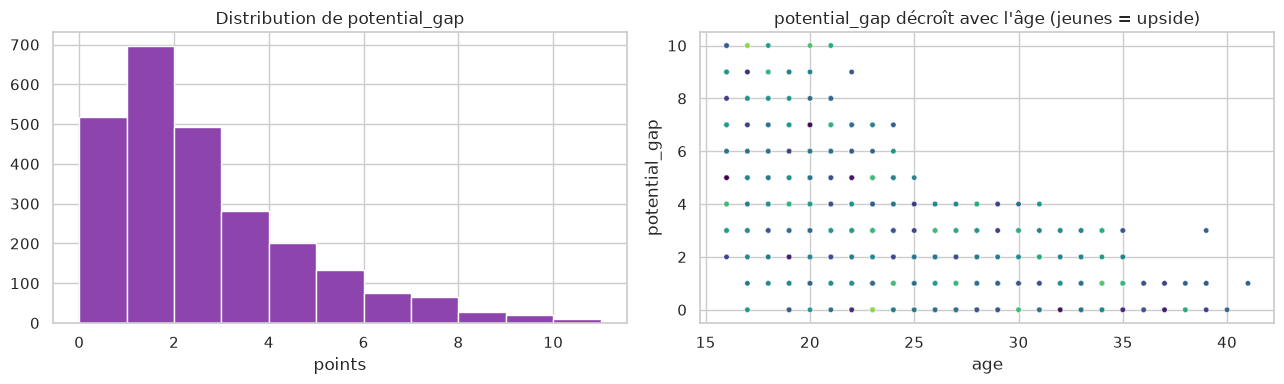

In [5]:
df['potential_gap'] = df['potential'] - df['overall']
fig, ax = plt.subplots(1,2, figsize=(13,4))
ax[0].hist(df['potential_gap'], bins=range(0, int(df['potential_gap'].max())+2), color='#8e44ad')
ax[0].set_title('Distribution de potential_gap'); ax[0].set_xlabel('points')
sns.scatterplot(data=df.sample(min(2000,len(df))), x='age', y='potential_gap',
                hue='overall', palette='viridis', ax=ax[1], s=15, legend=False)
ax[1].set_title('potential_gap décroît avec l\'âge (jeunes = upside)')
plt.tight_layout(); plt.show()

**Conclusion** : `potential_gap` est concentré chez les jeunes, confirmant sa pertinence
métier. Il est calculé dans le pipeline par `PotentialGapTransformer` (source unique).

## 5. Variables catégorielles

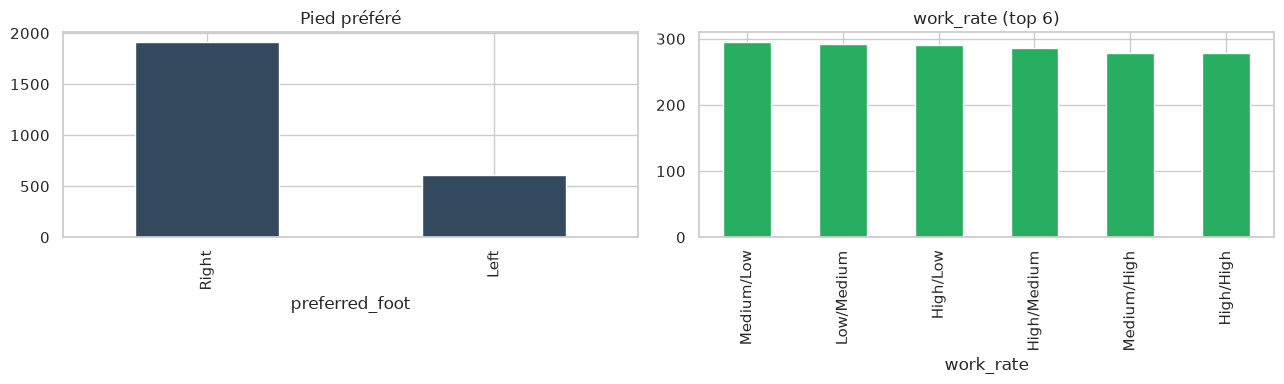

In [6]:
fig, ax = plt.subplots(1,2, figsize=(13,4))
df['preferred_foot'].value_counts().plot.bar(ax=ax[0], color='#34495e')
ax[0].set_title('Pied préféré')
df['work_rate'].value_counts().head(6).plot.bar(ax=ax[1], color='#27ae60')
ax[1].set_title("work_rate (top 6)")
plt.tight_layout(); plt.show()

## 6. Synthèse → décisions de modélisation

| Constat EDA | Décision |
|---|---|
| Cible très asymétrique | Transformation `log1p` de `value_eur` |
| `overall`/`potential` très corrélés | Conservés ; `potential_gap` ajouté comme signal métier |
| Stats GK nulles pour joueurs de champ | Imputation médiane/0 **dans le pipeline** (anti-fuite) |
| Catégorielles à faible cardinalité | One-Hot Encoding |
| Relations non strictement linéaires | Comparer linéaire (Ridge) vs ensembles (RF/GB) vs MLP |

Ces décisions sont implémentées dans `src/` et évaluées par validation croisée + tuning
dans `src/models/compare.py`.